In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Node, Material,
    # Sections
    Membrane,
    # Elements
    CST, LST, Quad4, Quad9,
    # Gmsh tools
    read_mesh, build_nodes, build_elements, build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average, plot_gmsh_mesh,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d ,
    # Units
    mm, cm, m, kgf, N, tf, kN, MPa, GPa, kg,
    # Parameters
    globalParameters,
)
# Standard libraries
import os
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 0.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [ ]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters
output_path = os.getcwd()
mesh_name = 'wrench'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
gmsh.initialize()
gmsh.model.add(output_file)

# Parameters
head_diameter_left   = 32
head_diameter_right  = 29
head_distance        = 110
ring_distance        = 55
ring_diameter        = 6.5
handle_width         = 11
fillet_radius_left   = 47
fillet_radius_right  = 23
inner_radius_left    = 13
inner_radius_right   = 9
offset_left          = 17
offset_right         = 13
delta_x_inner        = 6
delta_y_inner        = 2

head_radius_left  = head_diameter_left  / 2.0
head_radius_right = head_diameter_right / 2.0

# Central ring
p1 = gmsh.model.geo.addPoint(head_distance/2 - ring_distance/2,  0,                0, 1)
p2 = gmsh.model.geo.addPoint(head_distance/2 - ring_distance/2,  ring_diameter/2,  0, 1)
p3 = gmsh.model.geo.addPoint(head_distance/2 - ring_distance/2, -ring_diameter/2,  0, 1)
p4 = gmsh.model.geo.addPoint(head_distance/2 + ring_distance/2,  0,                0, 1)
p5 = gmsh.model.geo.addPoint(head_distance/2 + ring_distance/2,  ring_diameter/2,  0, 1)
p6 = gmsh.model.geo.addPoint(head_distance/2 + ring_distance/2, -ring_diameter/2,  0, 1)

l1   = gmsh.model.geo.addLine(p2, p5)
l2   = gmsh.model.geo.addLine(p6, p3)
arc1 = gmsh.model.geo.addCircleArc(p3, p1, p2)
arc2 = gmsh.model.geo.addCircleArc(p5, p4, p6)

# Handle geometry
half_width = handle_width / 2.0

R1 = head_radius_left
R2 = fillet_radius_left
dx_left   = math.sqrt(R1**2 + 2*R2*(R1 - half_width) - half_width**2)
sin_theta = dx_left / (R1 + R2)
cos_theta = (half_width + R2) / (R1 + R2)
x_left    = R1 * sin_theta
y_left    = R1 * cos_theta

R1 = head_radius_right
R2 = fillet_radius_right
dx_right  = math.sqrt(R1**2 + 2*R2*(R1 - half_width) - half_width**2)
sin_theta = dx_right / (R1 + R2)
cos_theta = (half_width + R2) / (R1 + R2)
x_right   = R1 * sin_theta
y_right   = R1 * cos_theta

pm1  = gmsh.model.geo.addPoint(x_left,                   y_left,                           0, 1)
pm2  = gmsh.model.geo.addPoint(x_left,                  -y_left,                           0, 1)
pm3  = gmsh.model.geo.addPoint(dx_left,                  half_width,                       0, 1)
pm4  = gmsh.model.geo.addPoint(dx_left,                 -half_width,                       0, 1)
pm5  = gmsh.model.geo.addPoint(head_distance - dx_right, half_width,                       0, 1)
pm6  = gmsh.model.geo.addPoint(head_distance - dx_right,-half_width,                       0, 1)
pm7  = gmsh.model.geo.addPoint(head_distance - x_right,  y_right,                          0, 1)
pm8  = gmsh.model.geo.addPoint(head_distance - x_right, -y_right,                          0, 1)
pm9  = gmsh.model.geo.addPoint(dx_left,                  half_width  + fillet_radius_left,  0, 1)
pm10 = gmsh.model.geo.addPoint(dx_left,                 -half_width  - fillet_radius_left,  0, 1)
pm11 = gmsh.model.geo.addPoint(head_distance - dx_right, half_width  + fillet_radius_right, 0, 1)
pm12 = gmsh.model.geo.addPoint(head_distance - dx_right,-half_width  - fillet_radius_right, 0, 1)
pc1  = gmsh.model.geo.addPoint(0,             0, 0, 1)
pc2  = gmsh.model.geo.addPoint(head_distance, 0, 0, 1)

lm1   = gmsh.model.geo.addLine(pm3, pm5)
lm2   = gmsh.model.geo.addLine(pm4, pm6)
arc_m1 = gmsh.model.geo.addCircleArc(pm1, pm9,  pm3)
arc_m2 = gmsh.model.geo.addCircleArc(pm2, pm10, pm4)
arc_m3 = gmsh.model.geo.addCircleArc(pm5, pm11, pm7)
arc_m4 = gmsh.model.geo.addCircleArc(pm6, pm12, pm8)
arc_m5 = gmsh.model.geo.addCircleArc(pm1, pc1,  pm2)
arc_m6 = gmsh.model.geo.addCircleArc(pm7, pc2,  pm8)

# Left head
alpha_left = math.asin((offset_left / 2.0) / head_radius_left)
theta      = math.atan(delta_y_inner / delta_x_inner)

pi1 = gmsh.model.geo.addPoint(-head_radius_left * math.cos(alpha_left - theta),  head_radius_left * math.sin(alpha_left - theta),  0, 1)
pi2 = gmsh.model.geo.addPoint(-head_radius_left * math.cos(-alpha_left - theta), head_radius_left * math.sin(-alpha_left - theta), 0, 1)
pi3 = gmsh.model.geo.addPoint(-head_radius_left * math.cos(alpha_left - theta)  + offset_left * math.cos(theta), head_radius_left * math.sin(alpha_left - theta)  + offset_left * math.sin(theta), 0, 1)
pi4 = gmsh.model.geo.addPoint(-head_radius_left * math.cos(-alpha_left - theta) + offset_left * math.cos(theta), head_radius_left * math.sin(-alpha_left - theta) + offset_left * math.sin(theta), 0, 1)
pc3 = gmsh.model.geo.addPoint(-delta_x_inner, -delta_y_inner, 0, 1)

li1    = gmsh.model.geo.addLine(pi1, pi3)
li2    = gmsh.model.geo.addLine(pi2, pi4)
arc_i1 = gmsh.model.geo.addCircleArc(pm1, pc1, pi1)
arc_i2 = gmsh.model.geo.addCircleArc(pi2, pc1, pm2)
arc_i3 = gmsh.model.geo.addCircleArc(pi4, pc3, pi3)

# Right head
alpha_right = math.asin((offset_right / 2.0) / head_radius_right)

pi5 = gmsh.model.geo.addPoint(head_distance + head_radius_right * math.cos(alpha_right + theta),  head_radius_right * math.sin(alpha_right + theta),  0, 1)
pi6 = gmsh.model.geo.addPoint(head_distance + head_radius_right * math.cos(theta - alpha_right),  head_radius_right * math.sin(theta - alpha_right),  0, 1)
pi7 = gmsh.model.geo.addPoint(head_distance + head_radius_right * math.cos(alpha_right + theta) - offset_right * math.cos(theta), head_radius_right * math.sin(alpha_right + theta) - offset_right * math.sin(theta), 0, 1)
pi8 = gmsh.model.geo.addPoint(head_distance + head_radius_right * math.cos(theta - alpha_right) - offset_right * math.cos(theta), head_radius_right * math.sin(theta - alpha_right) - offset_right * math.sin(theta), 0, 1)
pc4 = gmsh.model.geo.addPoint(head_distance + delta_x_inner, delta_y_inner, 0, 1)

li3    = gmsh.model.geo.addLine(pi7, pi5)
li4    = gmsh.model.geo.addLine(pi8, pi6)
arc_i4 = gmsh.model.geo.addCircleArc(pm7, pc2, pi5)
arc_i5 = gmsh.model.geo.addCircleArc(pi6, pc2, pm8)
arc_i6 = gmsh.model.geo.addCircleArc(pi8, pc4, pi7)

# Surfaces
loop1    = gmsh.model.geo.addCurveLoop([-arc1, -l2, -arc2, -l1])
surface1 = gmsh.model.geo.addPlaneSurface([loop1])

loop2    = gmsh.model.geo.addCurveLoop([-arc_m1, -lm1, -arc_m3, -arc_m6, arc_m4, lm2, arc_m2, arc_m5])
loop3    = gmsh.model.geo.addCurveLoop([l1, arc2, l2, arc1])
surface2 = gmsh.model.geo.addPlaneSurface([loop2, loop3])

loop4    = gmsh.model.geo.addCurveLoop([li1, -arc_i3, -li2, arc_i2, -arc_m5, arc_i1])
surface3 = gmsh.model.geo.addPlaneSurface([loop4])

loop5    = gmsh.model.geo.addCurveLoop([-arc_i4, li3, arc_i6, -li4, -arc_i5, arc_m6])
surface4 = gmsh.model.geo.addPlaneSurface([loop5])

# Mesh settings
def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 10)

all_quads()
gmsh.model.geo.synchronize()

# Physical groups
gmsh.model.addPhysicalGroup(2, [surface3, surface4], 201)
gmsh.model.setPhysicalName(2, 201, "Head_5mm")

gmsh.model.addPhysicalGroup(2, [surface2], 202)
gmsh.model.setPhysicalName(2, 202, "Body_3mm")

gmsh.model.addPhysicalGroup(2, [surface1], 203)
gmsh.model.setPhysicalName(2, 203, "Body_1p6mm")

gmsh.model.addPhysicalGroup(1, [arc_i4], 101)
gmsh.model.setPhysicalName(1, 101, "LoadBoundary")

gmsh.model.addPhysicalGroup(1, [li1, arc_i3, li2], 102)
gmsh.model.setPhysicalName(1, 102, "RestrainBoundary")

gmsh.model.geo.synchronize()

gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 2)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 2)


In [6]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [7]:
# Unit conversions
GPa = 1000        # [MPa]
tf  = 1e6         # [N]
m   = 1000        # [mm]

# Material
PLA = Material(name='PLA', E=3.0*GPa, nu=0.40, rho=1.25*tf/m**3)

# Sections
Head   = Membrane(name='Head_5mm',    thickness=5,   material=PLA)
Body3  = Membrane(name='Body_3mm',    thickness=3,   material=PLA)
Body16 = Membrane(name='Body_1p6mm',  thickness=1.6, material=PLA)

# Dictionaries
section_dictionary = {
    201: Head,
    202: Body3,
    203: Body16,
}

load_dictionary = {
    101: {'value': 1, 'direction': '-y'},  
}

restrain_dictionary = {
    102: ['r', 'r'],
}

In [8]:
# Read raw mesh data from gmsh file
mesh = read_mesh(output_file)

# Instantiate Node objects and apply boundary conditions
node_map, nodes, system_nDof = build_nodes(mesh, restrain_dictionary)

  MESH SUMMARY

  === NODES ===  (859 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1        27.5000         3.2500         0.0000
       2        27.5000        -3.2500         0.0000
       3        82.5000         3.2500         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (5 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
     101      1   'LoadBoundary'
     102      1   'RestrainBoundary'
     201      2   'Head_5mm'
     202      2   'Body_3mm'
     203      2   'Body_1p6mm'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (5 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
     101

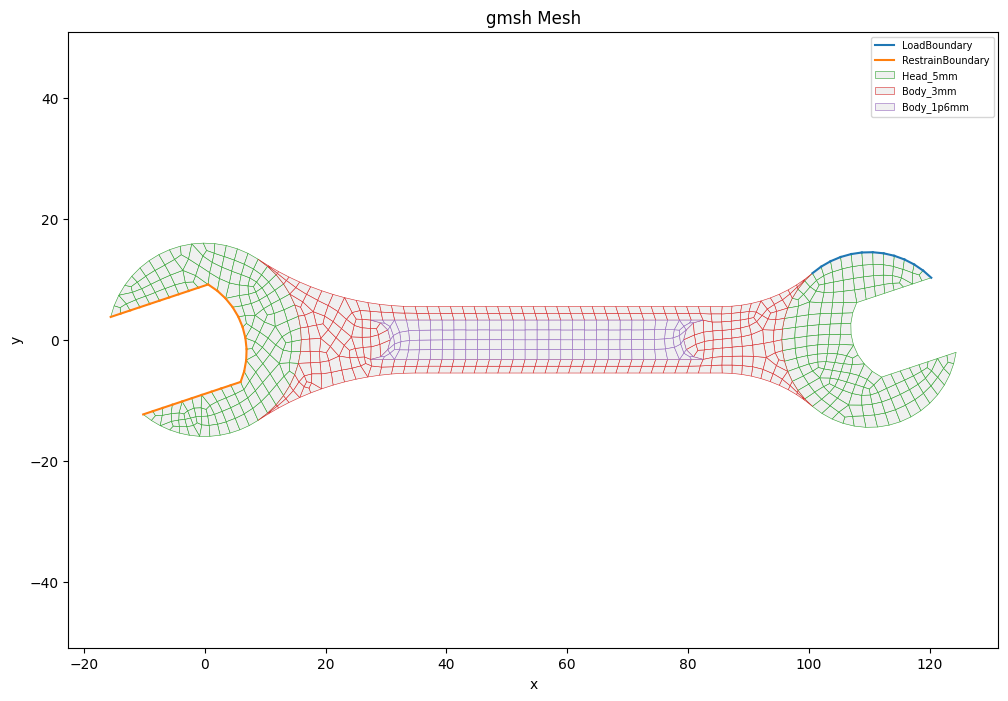

In [9]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [10]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Instantiate FEM element objects from mesh connectivity
elements = build_elements(  mesh=mesh,
                            node_map=node_map,
                            section_dictionary=section_dictionary,
                            element_class_map=element_map )

In [11]:
# Build global nodal force vector from load dictionary
F_load = build_load_vector(mesh=mesh, 
                            node_map=node_map, 
                            load_dictionary=load_dictionary)

In [12]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Global stiffness matrix (sparse)
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in nodes:
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in nodes])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Remove load on restrained DOFs (they go to reactions directly)
F[restrained_dofs] = 0.0

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]
Ff  = F[free_dofs]
Fr  = F[restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, Ff - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr      = Krf @ uf + Krr @ ur
R       = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [13]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [14]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [82.5   3.25]:  ux=+0.268713  uy=-3.029776
Node 17 at [120.24086   10.265222]:  ux=+0.908352  uy=-6.367447


In [15]:
# Reactions per node
for node in nodes:
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' *50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 13:  Rx=-0.274514  Ry=-1.079206
Node 14:  Rx=+1.700584  Ry=-1.350507
Node 15:  Rx=-23.830367  Ry=+3.993726
Node 16:  Rx=+41.292147  Ry=+15.941163
Node 207:  Rx=-0.797270  Ry=-2.165533
Node 208:  Rx=-1.005189  Ry=-2.147092
Node 209:  Rx=-1.249361  Ry=-2.136263
Node 210:  Rx=-1.519755  Ry=-2.094875
Node 211:  Rx=-1.859813  Ry=-1.979663
Node 212:  Rx=-2.294740  Ry=-1.728836
Node 213:  Rx=-2.914609  Ry=-1.246283
Node 214:  Rx=-3.755034  Ry=-0.167563
Node 215:  Rx=-5.354070  Ry=+2.066070
Node 216:  Rx=+3.727910  Ry=-2.429386
Node 217:  Rx=+4.013912  Ry=-2.080865
Node 218:  Rx=+4.344554  Ry=-1.661788
Node 219:  Rx=+4.894579  Ry=-1.380018
Node 220:  Rx=+5.358119  Ry=-0.653713
Node 221:  Rx=+6.370405  Ry=-0.447876
Node 222:  Rx=+7.556996  Ry=+0.792293
Node 223:  Rx=+9.381920  Ry=+1.854613
Node 224:  Rx=+11.225619  Ry=+4.483607
Node 251:  Rx=+30.305355  Ry=+5.526766
Node 252:  Rx=+17.231163  Ry=-0.756442
Node 253:  Rx=+7.942736  Ry=-0.123610
Node 254:  Rx=-4.527266  Ry=-2.818296
Node 255: 

In [16]:
# Prepare displacement data (convert 2D to 3D format for Gmsh)
u_3d = np.zeros((len(nodes), 3))
for i, node in enumerate(nodes):
    u_3d[i, 0] = u[node.idx[0]]  # Displacement in X
    u_3d[i, 1] = u[node.idx[1]]  # Displacement in Y

# Extract node tags for Gmsh
node_tags = np.array([node.name for node in nodes])

# Prepare applied forces (convert 2D to 3D format for Gmsh)
F_3d = np.zeros((len(nodes), 3))
for i, node in enumerate(nodes):
    F_3d[i, 0] = F[node.idx[0]]  # Force in X
    F_3d[i, 1] = F[node.idx[1]]  # Force in Y

# Prepare reaction forces (convert 2D to 3D format for Gmsh)
R_3d = np.zeros((len(nodes), 3))
for i, node in enumerate(nodes):
    R_3d[i, 0] = R[node.idx[0]]  # Reaction in X
    R_3d[i, 1] = R[node.idx[1]]  # Reaction in Y

# Initialize arrays for stress and strain results
sigma_gmsh = np.zeros((len(elements), 3))           # [σ_xx, σ_yy, σ_xy]
epsilon_gmsh = np.zeros((len(elements), 3))         # [ε_xx, ε_yy, ε_xy]
sigma_principal_gmsh = np.zeros((len(elements), 2)) # [σ_1, σ_2]
epsilon_principal_gmsh = np.zeros((len(elements), 2)) # [ε_1, ε_2]
von_mises_gmsh = np.zeros(len(elements))            # Von Mises stress

# Extract element tags for Gmsh
element_tags_list = []
for element in elements:
    element_tags_list.append(element.element_tag)

# Compute stress and strain for each element
for index, element in enumerate(elements):
    results = element.get_results(u)
    
    # Extract stress and strain components
    sigma = results['stress'].flatten()    # [σ_xx, σ_yy, σ_xy]
    epsilon = results['strain'].flatten()  # [ε_xx, ε_yy, ε_xy]
    
    sigma_gmsh[index, :] = sigma
    epsilon_gmsh[index, :] = epsilon
    
    # Extract principal values
    sigma_principal_gmsh[index, :] = results['principal_stress'].flatten()
    epsilon_principal_gmsh[index, :] = results['principal_strain'].flatten()
    
    # Calculate Von Mises stress for 2D plane stress
    sxx, syy, sxy = sigma
    von_mises = np.sqrt(sxx**2 - sxx*syy + syy**2)
    von_mises_gmsh[index] = von_mises

In [17]:
# VISUALIZE RESULTS IN GMSH
gmsh.initialize()
gmsh.open(output_file)

# Extract node tags
node_tags = np.array([node.name for node in nodes])

# --- Nodal vector fields ---
# Displacements: VectorType=5 deforms mesh, DisplacementFactor=5 scales deformation for visibility
# 1 → Line segments (simple lines)
# 2 → Arrows 
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation
add_node_data_view("Displacements", 
                   node_tags, 
                   u_3d, 
                   vector_type=5, 
                   displacement_factor=5)

add_node_data_view("Applied Loads", 
                   node_tags, 
                   F_3d)

add_node_data_view("Reactions", 
                   node_tags, 
                   R_3d)

2

In [18]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [19]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [20]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [21]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, sigma_gmsh[:, 0], nodes)
add_node_data_view("Sxx Nodal Averaged", 
                   node_tags, 
                   sxx_nodal)

syy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 1], nodes)
add_node_data_view("Syy Nodal Averaged",
                    node_tags, 
                    syy_nodal)

sxy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 2], nodes)
add_node_data_view("Sxy Nodal Averaged",
                    node_tags, 
                    sxy_nodal)

s1_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 0], nodes)
add_node_data_view("Principal Stress S1 Nodal Averaged",
                    node_tags,
                    s1_nodal)

s2_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 1], nodes)
add_node_data_view("Principal Stress S2 Nodal Averaged",
                    node_tags,
                    s2_nodal)

vm_nodal = compute_nodal_average(elements, von_mises_gmsh, nodes)
add_node_data_view("Von Mises Nodal Averaged", 
                   node_tags, 
                   vm_nodal)

# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

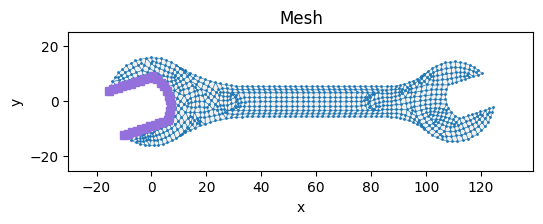

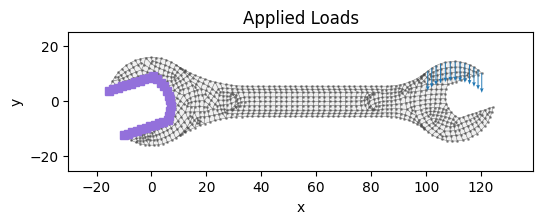

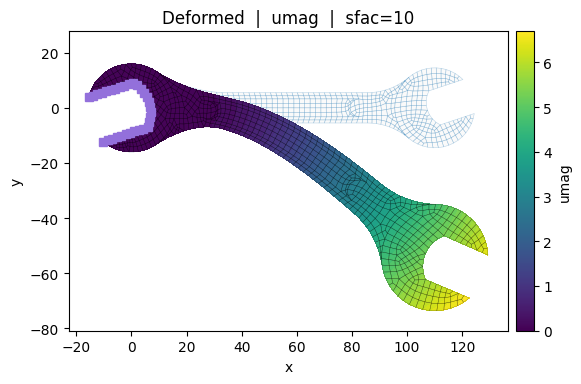

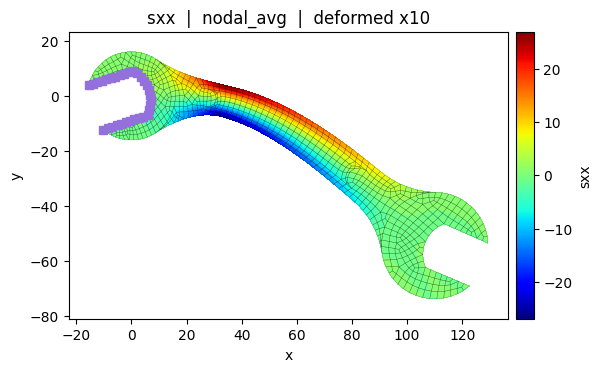

In [22]:
# Mesh
plot_mesh(
    nodes               = nodes,
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,   
)


# Loads
plot_loads_2d(
    nodes    = nodes,
    elements = elements,
    F_load   = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize  = (6, 6),
    ax       = None,
    save     = None,    
)

# Deformed
plot_deformed(
    nodes     = nodes,
    elements  = elements,
    u         = u,
    component = 'umag',   # 'ux', 'uy', 'umag'
    sfac      = 10,
    cmap      = 'viridis',
    limit               = None,      
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes       = nodes,
    elements    = elements,
    u           = u,
    component   = 'sxx',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed    = True,
    sfac        = 10,
    limit       = None,         # e.g. (-250, 250) highlights elements outside range in red
    # levels      = 20,
    cmap        = 'jet',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,
)